# 05_clustering_rfm

Notebook này thực hiện pipeline phân cụm khách hàng trên **RFM** và tạo artifact để dùng lại cho **báo cáo** và **Streamlit**.

## Mục tiêu kỹ thuật
1. Đọc `rfm_df` và (nếu có) `orders_base_final`
2. Làm sạch và chuẩn hóa dữ liệu RFM
3. Giảm lệch phân phối bằng `log1p`
4. Chuẩn hóa bằng `StandardScaler`
5. Khảo sát `K=2..10` cho `KMeans`
6. Khảo sát `n_components=2..10` và nhiều `covariance_type` cho `GaussianMixture`
7. So sánh bằng `silhouette`, `calinski_harabasz`, `davies_bouldin`, `inertia`, `BIC`
8. Tạo **cluster profile**, **business segment name**, **business strategy**
9. Lưu model, scaler, PCA, metrics, plots và dataset đã gán cluster

## Quy tắc chọn K trong notebook này
Notebook **không trộn lẫn** hai khái niệm:

- **K tối ưu theo metric**: dùng cho phân tích thống kê khách quan.
- **K chốt để triển khai**: dùng cho profile cụm, artifact cuối, báo cáo và UI.

> Với file này, notebook vẫn **ghi nhận K tối ưu theo metric** và đồng thời **chốt KMeans = 4** cho phần triển khai cuối. Cách làm này giúp báo cáo không mâu thuẫn với số liệu trong notebook.


> **Lưu ý đồng bộ output:** Notebook này đã được hoàn thiện lại logic nguồn và markdown.  
> Nếu đang mở từ bản cũ có output đã lưu trước đó, hãy **Run All** để refresh bảng profile, summary và artifact cuối cho đúng với source hiện tại.


## Cell 1: Import thư viện cần thiết

In [1]:

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from IPython.display import display, Markdown

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score
)


## Cell 2: Khai báo cấu hình chung cho notebook clustering

In [2]:

# =========================
# CONFIG
# =========================
def locate_project_base():
    candidates = [
        Path(".."),
        Path("."),
        Path("../..")
    ]
    for base in candidates:
        if (base / "data" / "processed").exists():
            return base
    return Path("..")

BASE_DIR = locate_project_base()
PROCESSED_DIR = BASE_DIR / "data" / "processed"
ARTIFACT_DIR = BASE_DIR / "artifacts"

MODEL_DIR = ARTIFACT_DIR / "models"
METRIC_DIR = ARTIFACT_DIR / "metrics"
PLOT_DIR = ARTIFACT_DIR / "plots"
PRED_DIR = ARTIFACT_DIR / "predictions"

for folder in [MODEL_DIR, METRIC_DIR, PLOT_DIR, PRED_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
K_RANGE = list(range(2, 11))
GMM_COVARIANCE_TYPES = ["full", "diag", "tied"]
USE_LOG1P_TRANSFORM = True

KMEANS_MIN_SHARE_THRESHOLD = 5.0
FORCE_KMEANS_K = 4  # chốt K cuối cho báo cáo/UI; notebook vẫn lưu K tối ưu theo metric riêng
FORCE_GMM_COMPONENTS = None   # để None nếu chỉ ép KMeans

RFM_ID_COL = "customer_unique_id"
RFM_FEATURES = ["recency_days", "frequency_orders", "monetary_value"]

print("BASE_DIR:", BASE_DIR.resolve())
print("PROCESSED_DIR:", PROCESSED_DIR.resolve())
print("ARTIFACT_DIR:", ARTIFACT_DIR.resolve())
print("K_RANGE:", K_RANGE)
print("GMM_COVARIANCE_TYPES:", GMM_COVARIANCE_TYPES)


BASE_DIR: C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project
PROCESSED_DIR: C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\data\processed
ARTIFACT_DIR: C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\artifacts
K_RANGE: [2, 3, 4, 5, 6, 7, 8, 9, 10]
GMM_COVARIANCE_TYPES: ['full', 'diag', 'tied']


## Cell 3: Định nghĩa các hàm hỗ trợ

In [3]:

# =========================
# HELPER FUNCTIONS
# =========================
def load_table(preferred_stem):
    parquet_path = PROCESSED_DIR / f"{preferred_stem}.parquet"
    csv_path = PROCESSED_DIR / f"{preferred_stem}.csv"

    if parquet_path.exists():
        return pd.read_parquet(parquet_path), parquet_path
    if csv_path.exists():
        return pd.read_csv(csv_path), csv_path

    raise FileNotFoundError(f"Không tìm thấy file cho stem: {preferred_stem}")

def to_python_scalar(value):
    if isinstance(value, (np.integer, np.int64, np.int32)):
        return int(value)
    if isinstance(value, (np.floating, np.float64, np.float32)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    return value

def top_mode(series, default="unknown"):
    s = series.dropna().astype(str)
    if s.empty:
        return default
    mode_vals = s.mode()
    return mode_vals.iloc[0] if not mode_vals.empty else default

def safe_z(series):
    std = series.std(ddof=0)
    if std == 0 or pd.isna(std):
        return pd.Series(0.0, index=series.index)
    return (series - series.mean()) / std

def assign_segment_names(profile_df, label_col):
    out = profile_df.copy().sort_values(label_col).reset_index(drop=True)

    out["business_score"] = (
        safe_z(out["frequency_orders_mean"])
        + safe_z(out["monetary_value_mean"])
        - safe_z(out["recency_days_mean"])
    ).round(4)

    n_clusters = len(out)
    recency_q25 = out["recency_days_mean"].quantile(0.25)
    recency_median = out["recency_days_mean"].median()
    freq_q75 = out["frequency_orders_mean"].quantile(0.75)
    monetary_q75 = out["monetary_value_mean"].quantile(0.75)
    monetary_median = out["monetary_value_mean"].median()

    segment_names = []
    business_strategies = []
    used_names = {}

    for _, row in out.iterrows():
        if n_clusters <= 2:
            if (
                row["frequency_orders_mean"] >= freq_q75
                and row["monetary_value_mean"] >= monetary_q75
            ):
                name = "VIP / Repeat buyers"
                strategy = "Ưu tiên loyalty, upsell và giữ chân."
            else:
                name = "Mass / one-time customers"
                strategy = "Tăng repeat rate bằng cross-sell cơ bản và voucher nhẹ."
        else:
            if (
                row["frequency_orders_mean"] >= freq_q75
                and row["monetary_value_mean"] >= monetary_q75
            ):
                name = "VIP / Repeat buyers"
                strategy = "Upsell, loyalty và chăm sóc cá nhân hóa."
            elif row["recency_days_mean"] <= recency_q25:
                name = "Recent active"
                strategy = "Cross-sell sản phẩm liên quan và giữ nhịp mua tiếp theo."
            elif (
                row["monetary_value_mean"] >= monetary_median
                and row["recency_days_mean"] >= recency_median
            ):
                name = "High-value lapsed"
                strategy = "Win-back campaign cho nhóm từng chi tiêu cao nhưng đã rời xa."
            else:
                name = "Low-value lapsed"
                strategy = "Voucher tái kích hoạt chi phí thấp để kéo đơn hàng quay lại."

        used_names[name] = used_names.get(name, 0) + 1
        if used_names[name] > 1:
            name = f"{name} ({used_names[name]})"

        segment_names.append(name)
        business_strategies.append(strategy)

    out["segment_name"] = segment_names
    out["business_strategy"] = business_strategies
    return out

def build_cluster_profile(clustered_df, label_col):
    profile = (
        clustered_df
        .groupby(label_col, as_index=False)
        .agg(
            customer_count=(RFM_ID_COL, "nunique"),
            recency_days_mean=("recency_days", "mean"),
            recency_days_median=("recency_days", "median"),
            frequency_orders_mean=("frequency_orders", "mean"),
            frequency_orders_median=("frequency_orders", "median"),
            monetary_value_mean=("monetary_value", "mean"),
            monetary_value_median=("monetary_value", "median")
        )
        .sort_values(label_col)
        .reset_index(drop=True)
    )

    total_customers = profile["customer_count"].sum()
    profile["customer_share_pct"] = (profile["customer_count"] / total_customers * 100).round(2)
    profile = assign_segment_names(profile, label_col)

    return profile

def enrich_cluster_profile(profile_df, clustered_df, label_col, orders_base_df=None):
    if orders_base_df is None:
        return profile_df.copy()

    required_cols = [
        "customer_unique_id",
        "order_id",
        "review_score",
        "payment_value_sum",
        "delivery_time_days",
        "customer_state",
        "main_category"
    ]

    available_cols = [c for c in required_cols if c in orders_base_df.columns]
    if "customer_unique_id" not in available_cols or "order_id" not in available_cols:
        return profile_df.copy()

    source = orders_base_df[available_cols].copy()

    if "review_score" in source.columns:
        source["review_score"] = pd.to_numeric(source["review_score"], errors="coerce")

    merged = source.merge(
        clustered_df[[RFM_ID_COL, label_col]],
        on="customer_unique_id",
        how="inner"
    )

    enriched = (
        merged.groupby(label_col, as_index=False)
        .agg(
            order_count=("order_id", "nunique"),
            avg_review_score=("review_score", "mean") if "review_score" in merged.columns else ("order_id", "count"),
            avg_payment_value=("payment_value_sum", "mean") if "payment_value_sum" in merged.columns else ("order_id", "count"),
            avg_delivery_time=("delivery_time_days", "mean") if "delivery_time_days" in merged.columns else ("order_id", "count"),
            top_state=("customer_state", lambda x: top_mode(x, default="unknown")) if "customer_state" in merged.columns else ("order_id", "count"),
            top_category=("main_category", lambda x: top_mode(x, default="unknown")) if "main_category" in merged.columns else ("order_id", "count")
        )
    )

    out = profile_df.merge(enriched, on=label_col, how="left")

    # Nếu vì thiếu cột mà sinh cột count tạm, bỏ đi hoặc chuẩn hóa giá trị
    for col in ["avg_review_score", "avg_payment_value", "avg_delivery_time"]:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    return out

def choose_best_kmeans(metrics_df, min_share_pct=5.0):
    filtered = metrics_df[metrics_df["min_cluster_share_pct"] >= min_share_pct].copy()

    if filtered.empty:
        filtered = metrics_df.copy()

    return (
        filtered
        .sort_values(
            by=["silhouette", "calinski_harabasz", "davies_bouldin", "k"],
            ascending=[False, False, True, True]
        )
        .iloc[0]
    )

def choose_best_gmm(metrics_df):
    return (
        metrics_df
        .sort_values(
            by=["silhouette", "bic", "calinski_harabasz", "davies_bouldin", "n_components"],
            ascending=[False, True, False, True, True]
        )
        .iloc[0]
    )

def make_cluster_scatter(pca_df, label_col, title, save_path):
    fig, ax = plt.subplots(figsize=(9, 6))
    unique_labels = sorted(pca_df[label_col].dropna().unique())

    for label in unique_labels:
        subset = pca_df[pca_df[label_col] == label]
        ax.scatter(
            subset["pc1"],
            subset["pc2"],
            label=f"Cluster {label}",
            alpha=0.70,
            s=25
        )

    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

def make_line_plot(df, x_col, y_col, title, xlabel, ylabel, save_path):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(df[x_col], df[y_col], marker="o")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


## Cell 4: Đọc dữ liệu đầu vào

In [4]:

# =========================
# LOAD DATA
# =========================
rfm_df, rfm_path = load_table("rfm_df")
print("Đã đọc:", rfm_path)

orders_base_final = None
orders_base_source = None

try:
    orders_base_final, orders_base_source = load_table("orders_base_final")
    print("Đã đọc thêm để enrich profile:", orders_base_source)
except Exception as e:
    print("Không đọc được orders_base_final. Notebook vẫn chạy bình thường.")
    print("Chi tiết:", e)

display(Markdown("### 5 dòng đầu của rfm_df"))
display(rfm_df.head())

print("rfm_df shape:", rfm_df.shape)


Đã đọc: ..\data\processed\rfm_df.parquet
Đã đọc thêm để enrich profile: ..\data\processed\orders_base_final.parquet


### 5 dòng đầu của rfm_df

,customer_unique_id,recency_days,frequency_orders,monetary_value
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


rfm_df shape: (93358, 4)


## Cell 5: Kiểm tra và làm sạch dữ liệu RFM

In [5]:

# =========================
# VALIDATE & CLEAN RFM
# =========================
required_cols = [RFM_ID_COL] + RFM_FEATURES
missing_required_cols = [c for c in required_cols if c not in rfm_df.columns]
if missing_required_cols:
    raise KeyError(f"Thiếu cột bắt buộc trong rfm_df: {missing_required_cols}")

rfm = rfm_df[required_cols].copy()

# Chuẩn hóa kiểu dữ liệu
for col in RFM_FEATURES:
    rfm[col] = pd.to_numeric(rfm[col], errors="coerce")

# Loại duplicate customer nếu có
dup_customer_count = rfm.duplicated(subset=[RFM_ID_COL]).sum()
if dup_customer_count > 0:
    rfm = rfm.drop_duplicates(subset=[RFM_ID_COL], keep="last").copy()

# Quy tắc làm sạch cơ bản
rfm.loc[rfm["recency_days"] < 0, "recency_days"] = np.nan
rfm.loc[rfm["frequency_orders"] <= 0, "frequency_orders"] = np.nan
rfm.loc[rfm["monetary_value"] < 0, "monetary_value"] = np.nan

before_drop_shape = rfm.shape
rfm = rfm.dropna(subset=RFM_FEATURES).copy()
after_drop_shape = rfm.shape

cleaning_summary = pd.DataFrame({
    "metric": [
        "rows_before_cleaning",
        "rows_after_cleaning",
        "rows_dropped",
        "duplicate_customers_removed"
    ],
    "value": [
        before_drop_shape[0],
        after_drop_shape[0],
        before_drop_shape[0] - after_drop_shape[0],
        dup_customer_count
    ]
})

display(Markdown("### Cleaning summary"))
display(cleaning_summary)

display(Markdown("### Missing values sau cleaning"))
display(rfm.isnull().sum())


### Cleaning summary

,metric,value
0,rows_before_cleaning,93358
1,rows_after_cleaning,93358
2,rows_dropped,0
3,duplicate_customers_removed,0


### Missing values sau cleaning

customer_unique_id    0
recency_days          0
frequency_orders      0
monetary_value        0
dtype: int64

## Cell 6: Thống kê mô tả dữ liệu RFM

### RFM describe + skewness

,count,mean,std,min,25%,50%,75%,max,skewness
recency_days,93358.0,237.941773,152.591453,1.0,114.0000,219.00,346.0000,714.00,0.447434
frequency_orders,93358.0,1.033420,0.209097,1.0,1.0000,1.00,1.0000,15.00,11.095156
monetary_value,93358.0,165.197003,226.314012,0.0,63.0525,107.78,182.5575,13664.08,9.210981


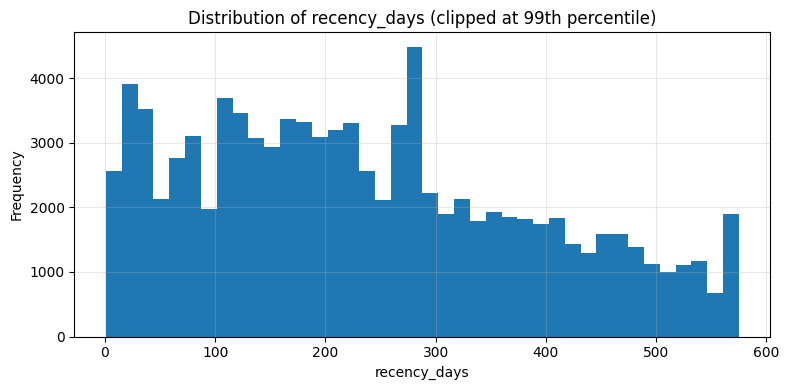

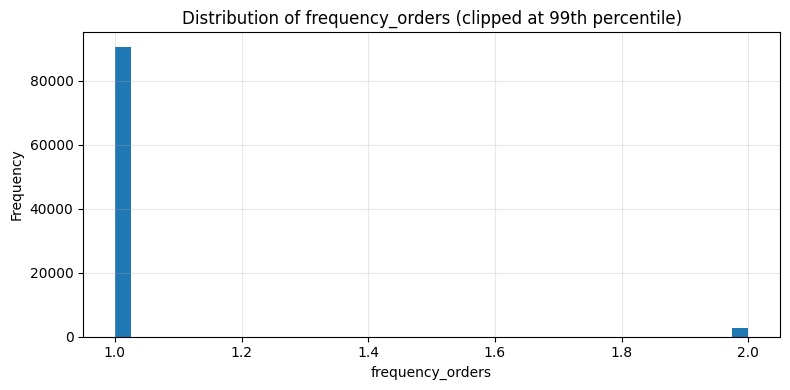

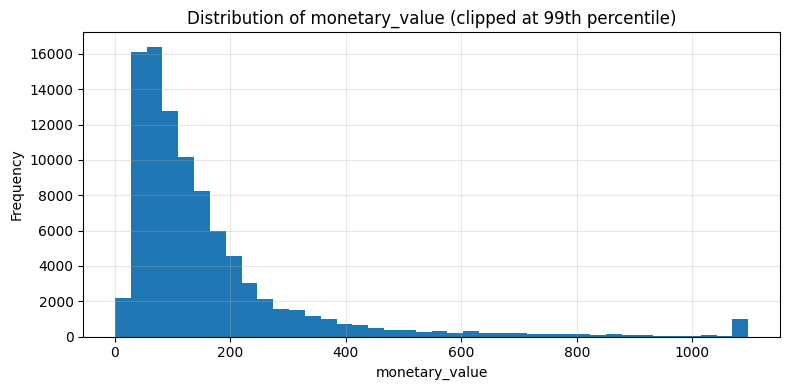

In [6]:

# =========================
# THỐNG KÊ MÔ TẢ RFM
# =========================
rfm_describe = rfm[RFM_FEATURES].describe().T
rfm_describe["skewness"] = rfm[RFM_FEATURES].skew()

display(Markdown("### RFM describe + skewness"))
display(rfm_describe)

# Plot nhanh để xem phân phối
for col in RFM_FEATURES:
    plt.figure(figsize=(8, 4))
    rfm[col].clip(upper=rfm[col].quantile(0.99)).plot(kind="hist", bins=40)
    plt.title(f"Distribution of {col} (clipped at 99th percentile)")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Cell 7: Chuẩn bị feature cho clustering

In [7]:

# =========================
# CHUẨN BỊ FEATURE CHO CLUSTERING
# - Giữ nguyên bản gốc để profile business
# - Dùng log1p để giảm skew nếu bật cấu hình
# - StandardScaler là bước chuẩn hóa chính theo yêu cầu đồ án
# =========================
rfm_features_original = rfm[RFM_FEATURES].copy()

if USE_LOG1P_TRANSFORM:
    rfm_features_model = np.log1p(rfm_features_original)
else:
    rfm_features_model = rfm_features_original.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_features_model)

scaled_df = pd.DataFrame(X_scaled, columns=[f"{c}_scaled" for c in RFM_FEATURES])

display(Markdown("### 5 dòng đầu của dữ liệu dùng cho clustering"))
display(pd.concat([rfm[[RFM_ID_COL]].head(), rfm_features_original.head(), scaled_df.head()], axis=1))

print("X_scaled shape:", X_scaled.shape)


### 5 dòng đầu của dữ liệu dùng cho clustering

,customer_unique_id,recency_days,frequency_orders,monetary_value,recency_days_scaled,frequency_orders_scaled,monetary_value_scaled
0,0000366f3b9a7992bf8c76cfdf3221e2,112.0,1.0,141.90,-0.470398,-0.17019,0.288247
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115.0,1.0,27.19,-0.442315,-0.17019,-1.719399
2,0000f46a3911fa3c0805444483337064,537.0,1.0,86.22,1.202027,-0.17019,-0.322406
3,0000f6ccb0745a6a4b88665a16c9f078,321.0,1.0,43.62,0.651893,-0.17019,-1.151414
4,0004aac84e0df4da2b147fca70cf8255,288.0,1.0,196.89,0.536011,-0.17019,0.690927


X_scaled shape: (93358, 3)


## Cell 8: Giảm chiều dữ liệu bằng PCA để trực quan hóa

In [8]:

# =========================
# PCA 2D CHO TRỰC QUAN HÓA
# =========================
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca_2d.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    RFM_ID_COL: rfm[RFM_ID_COL].values,
    "pc1": X_pca[:, 0],
    "pc2": X_pca[:, 1]
})

explained_var = pd.DataFrame({
    "component": ["PC1", "PC2"],
    "explained_variance_ratio": pca_2d.explained_variance_ratio_
})

display(Markdown("### PCA explained variance"))
display(explained_var)


### PCA explained variance

,component,explained_variance_ratio
0,PC1,0.388538
1,PC2,0.333041


## KMeans: khảo sát K từ 2 đến 10

Phần này tính cho từng `k`:

- `inertia` để đọc **Elbow**
- `silhouette_score`
- `calinski_harabasz_score`
- `davies_bouldin_score`
- `min_cluster_share_pct` để kiểm tra cluster quá nhỏ

**Lưu ý quan trọng:**

- Notebook luôn xác định **K tối ưu theo metric** một cách riêng biệt.
- Nếu `FORCE_KMEANS_K` khác `None`, notebook vẫn có thể **chốt một K khác** cho phần triển khai cuối cùng.
- Vì vậy trong báo cáo phải tách bạch:
  - **K tối ưu theo metric**
  - **K chốt để triển khai / báo cáo / UI**


## Cell 9: Khảo sát KMeans với nhiều giá trị k

In [9]:

# =========================
# KMEANS MODEL SELECTION
# =========================
kmeans_selection_results = []

for k in K_RANGE:
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        max_iter=500,
        random_state=RANDOM_STATE
    )
    labels = model.fit_predict(X_scaled)

    cluster_share = pd.Series(labels).value_counts(normalize=True).mul(100)
    min_cluster_share_pct = cluster_share.min()

    result = {
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels),
        "min_cluster_share_pct": min_cluster_share_pct
    }
    kmeans_selection_results.append(result)

kmeans_metrics_df = pd.DataFrame(kmeans_selection_results)
display(Markdown("### KMeans selection metrics"))
display(kmeans_metrics_df)


### KMeans selection metrics

,k,inertia,silhouette,calinski_harabasz,davies_bouldin,min_cluster_share_pct
0,2,190214.602093,0.715384,44102.365742,0.469991,3.000278
1,3,129158.391848,0.421144,54540.681904,0.834458,3.000278
2,4,82907.903590,0.395254,74003.150482,0.756469,3.000278
3,5,68332.569968,0.357850,72318.209385,0.811624,3.000278
4,6,58433.329853,0.354792,70819.003423,0.800568,3.000278
5,7,51228.917084,0.354359,69502.733276,0.803065,3.000278
6,8,45847.951919,0.347073,68129.645704,0.842111,3.000278
7,9,41486.970558,0.340993,67106.212921,0.815172,3.000278
8,10,36709.165896,0.342001,68762.848222,0.830882,0.244221


## Cell 10: Lưu metric KMeans và vẽ biểu đồ chọn k

Đã lưu: ..\artifacts\metrics\kmeans_k_selection_metrics.csv


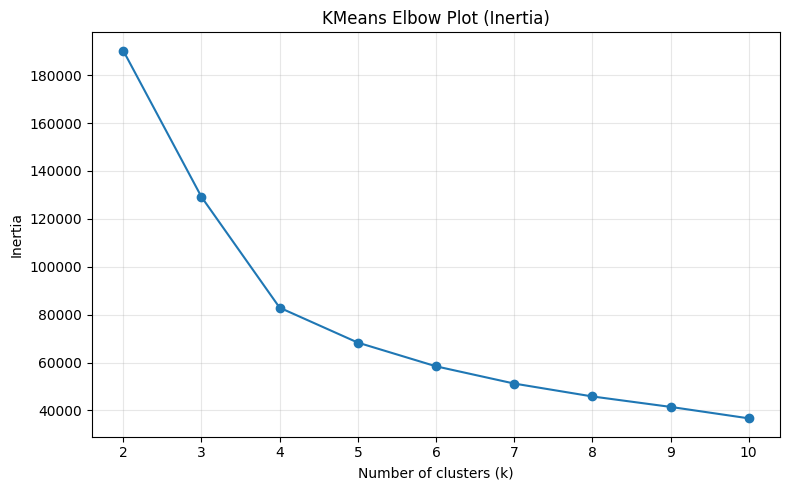

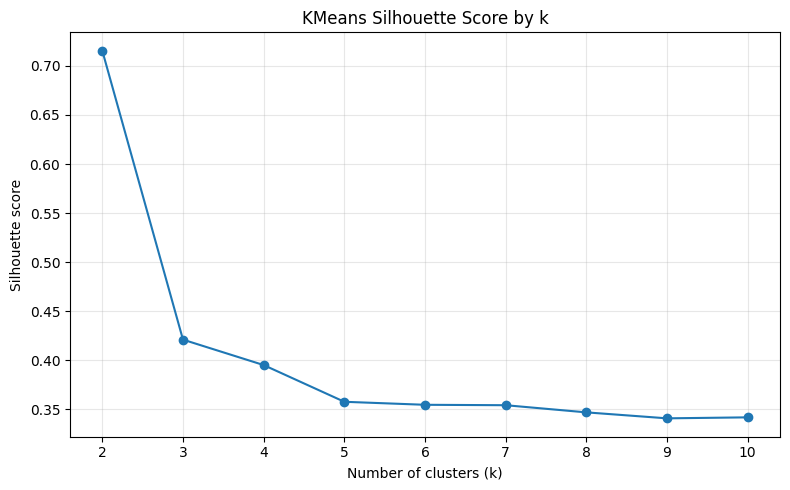

In [10]:

# =========================
# LƯU METRICS KMEANS + VẼ PLOT
# =========================
kmeans_metrics_path = METRIC_DIR / "kmeans_k_selection_metrics.csv"
kmeans_metrics_df.to_csv(kmeans_metrics_path, index=False)
print("Đã lưu:", kmeans_metrics_path)

kmeans_elbow_plot_path = PLOT_DIR / "kmeans_elbow_plot.png"
make_line_plot(
    kmeans_metrics_df,
    x_col="k",
    y_col="inertia",
    title="KMeans Elbow Plot (Inertia)",
    xlabel="Number of clusters (k)",
    ylabel="Inertia",
    save_path=kmeans_elbow_plot_path
)

kmeans_silhouette_plot_path = PLOT_DIR / "kmeans_silhouette_plot.png"
make_line_plot(
    kmeans_metrics_df,
    x_col="k",
    y_col="silhouette",
    title="KMeans Silhouette Score by k",
    xlabel="Number of clusters (k)",
    ylabel="Silhouette score",
    save_path=kmeans_silhouette_plot_path
)


## Giải thích kết quả chọn K cho KMeans

Notebook này lưu **hai mức kết luận**:

| Vai trò | K | Silhouette | Calinski-Harabasz | Davies-Bouldin | Cách hiểu |
|---|---:|---:|---:|---:|---|
| **K tối ưu theo metric** | **2** | **0.7154** | 44102.37 | **0.4700** | Tách lớp tốt nhất về mặt compactness/separation |
| **K chốt để triển khai** | **4** | 0.3953 | **74003.15** | 0.7565 | Hy sinh một phần silhouette để có 4 nhóm khách hàng hành động được |

### Vì sao vẫn chốt K = 4?
- `K=2` cho chỉ số silhouette rất mạnh, nhưng chia khách hàng quá thô: phần lớn khách nằm trong một cụm lớn, khó xây chiến lược marketing riêng.
- `K=4` tách được các nhóm **VIP / Repeat buyers**, **Recent active**, **High-value lapsed**, **Low-value lapsed**.
- Mục tiêu cuối của dự án không chỉ là metric clustering, mà còn là **insight kinh doanh + artifact dùng được cho báo cáo/UI**.

> Quy tắc dùng trong notebook này: **ghi nhận K tối ưu = 2**, nhưng **chốt K cuối = 4**.


## Cell 11: Huấn luyện mô hình KMeans cuối cùng

Cell này làm 3 việc:

1. Tìm **K tối ưu theo metric** bằng `choose_best_kmeans(...)`
2. Nếu `FORCE_KMEANS_K` được bật, notebook vẫn **chốt K cuối theo nhu cầu business/reporting**
3. Lưu song song cả hai thông tin để tránh mâu thuẫn giữa số liệu và phần thảo luận

> Với notebook này, **K tối ưu theo metric được lưu riêng**, còn **K chốt cuối cùng vẫn là 4**.


In [11]:

# =========================
# FIT FINAL KMEANS
# =========================
metric_best_kmeans_row = choose_best_kmeans(
    kmeans_metrics_df,
    min_share_pct=KMEANS_MIN_SHARE_THRESHOLD
)
metric_best_k = int(metric_best_kmeans_row["k"])

eligible_share_df = kmeans_metrics_df[
    kmeans_metrics_df["min_cluster_share_pct"] >= KMEANS_MIN_SHARE_THRESHOLD
].copy()

if FORCE_KMEANS_K is not None:
    forced_rows = kmeans_metrics_df[kmeans_metrics_df["k"] == FORCE_KMEANS_K].copy()
    if forced_rows.empty:
        raise ValueError(f"FORCE_KMEANS_K={FORCE_KMEANS_K} không nằm trong K_RANGE")

    best_kmeans_row = forced_rows.iloc[0]
    selection_mode = "forced_manual_final"

    selection_reason = (
        f"K tối ưu theo metric là k={metric_best_k} "
        f"(silhouette={metric_best_kmeans_row['silhouette']:.4f}). "
        f"Tuy nhiên notebook chốt k={FORCE_KMEANS_K} để phục vụ phân khúc business, "
        f"giữ consistency với báo cáo/UI, và tách được 4 nhóm hành động rõ hơn."
    )
else:
    best_kmeans_row = metric_best_kmeans_row
    selection_mode = "metric_driven"
    selection_reason = (
        f"Chọn k={metric_best_k} theo silhouette là chính, sau đó tham chiếu "
        f"Calinski-Harabasz, Davies-Bouldin và min_cluster_share_pct."
    )

best_k = int(best_kmeans_row["k"])

metric_row = metric_best_kmeans_row.copy()
final_row = best_kmeans_row.copy()

kmeans_decision_df = pd.DataFrame([
    {
        "decision_type": "metric_optimal",
        "k": int(metric_row["k"]),
        "silhouette": float(metric_row["silhouette"]),
        "calinski_harabasz": float(metric_row["calinski_harabasz"]),
        "davies_bouldin": float(metric_row["davies_bouldin"]),
        "min_cluster_share_pct": float(metric_row["min_cluster_share_pct"]),
        "decision_note": "Tối ưu theo metric; dùng làm mốc tham chiếu thống kê."
    },
    {
        "decision_type": "final_selected",
        "k": int(final_row["k"]),
        "silhouette": float(final_row["silhouette"]),
        "calinski_harabasz": float(final_row["calinski_harabasz"]),
        "davies_bouldin": float(final_row["davies_bouldin"]),
        "min_cluster_share_pct": float(final_row["min_cluster_share_pct"]),
        "decision_note": "K cuối dùng cho profile cụm, artifact, báo cáo và Streamlit."
    }
])

display(Markdown("### KMeans decision summary"))
display(kmeans_decision_df)

if eligible_share_df.empty:
    display(Markdown(
        f"> Không có giá trị `k` nào đạt `min_cluster_share_pct >= {KMEANS_MIN_SHARE_THRESHOLD:.1f}%`. "
        "Vì vậy metric-best được chọn trên toàn bộ dải K, sau đó mới xét quyết định business cuối cùng."
    ))
else:
    display(Markdown(
        f"> Có {len(eligible_share_df)} giá trị `k` đạt điều kiện "
        f"`min_cluster_share_pct >= {KMEANS_MIN_SHARE_THRESHOLD:.1f}%`."
    ))

display(Markdown(f"> {selection_reason}"))

print("Final KMeans k:", best_k)

final_kmeans = KMeans(
    n_clusters=best_k,
    init="k-means++",
    n_init=20,
    max_iter=500,
    random_state=RANDOM_STATE
)

kmeans_labels = final_kmeans.fit_predict(X_scaled)

rfm_clustered_kmeans = rfm[[RFM_ID_COL] + RFM_FEATURES].copy()
rfm_clustered_kmeans["cluster_kmeans"] = kmeans_labels

display(Markdown("### 5 dòng đầu của rfm_clustered_kmeans"))
display(rfm_clustered_kmeans.head())


### KMeans decision summary

,decision_type,k,silhouette,calinski_harabasz,davies_bouldin,min_cluster_share_pct,decision_note
0,metric_optimal,2,0.715384,44102.365742,0.469991,3.000278,Tối ưu theo metric; dùng làm mốc tham chiếu th...
1,final_selected,4,0.395254,74003.150482,0.756469,3.000278,"K cuối dùng cho profile cụm, artifact, báo cáo..."


> Không có giá trị `k` nào đạt `min_cluster_share_pct >= 5.0%`. Vì vậy metric-best được chọn trên toàn bộ dải K, sau đó mới xét quyết định business cuối cùng.

> K tối ưu theo metric là k=2 (silhouette=0.7154). Tuy nhiên notebook chốt k=4 để phục vụ phân khúc business, giữ consistency với báo cáo/UI, và tách được 4 nhóm hành động rõ hơn.

Final KMeans k: 4


### 5 dòng đầu của rfm_clustered_kmeans

,customer_unique_id,recency_days,frequency_orders,monetary_value,cluster_kmeans
0,0000366f3b9a7992bf8c76cfdf3221e2,112.0,1.0,141.90,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115.0,1.0,27.19,1
2,0000f46a3911fa3c0805444483337064,537.0,1.0,86.22,1
3,0000f6ccb0745a6a4b88665a16c9f078,321.0,1.0,43.62,1
4,0004aac84e0df4da2b147fca70cf8255,288.0,1.0,196.89,0


## Cell 12: Xây dựng hồ sơ cụm cho KMeans

In [12]:

# =========================
# HỒ SƠ CLUSTER KMEANS
# =========================
kmeans_profile = build_cluster_profile(rfm_clustered_kmeans, "cluster_kmeans")
kmeans_profile = enrich_cluster_profile(
    kmeans_profile,
    rfm_clustered_kmeans,
    "cluster_kmeans",
    orders_base_df=orders_base_final
)

kmeans_profile = kmeans_profile.sort_values("business_score", ascending=False).reset_index(drop=True)

display(Markdown("### KMeans cluster profile"))
display(kmeans_profile)


### KMeans cluster profile

,cluster_kmeans,customer_count,recency_days_mean,recency_days_median,frequency_orders_mean,frequency_orders_median,monetary_value_mean,monetary_value_median,customer_share_pct,business_score,segment_name,business_strategy,order_count,avg_review_score,avg_payment_value,avg_delivery_time,top_state,top_category
0,2,2801,220.294538,199.0,2.113888,2.0,308.588793,225.550,3.00,2.6175,VIP / Repeat buyers,"Upsell, loyalty và chăm sóc cá nhân hóa.",5943,4.211849,145.955252,12.308521,SP,bed_bath_table
1,3,16172,42.260388,38.0,1.000000,1.0,133.538781,103.675,17.32,0.4390,Recent active,Cross-sell sản phẩm liên quan và giữ nhịp mua ...,16217,4.311725,133.641172,8.597179,SP,health_beauty
2,0,32165,272.524887,255.0,1.000000,1.0,295.934306,199.400,34.45,-0.3493,High-value lapsed,Win-back campaign cho nhóm từng chi tiêu cao n...,32216,4.041832,296.091671,14.445166,SP,bed_bath_table
3,1,42220,287.719683,270.0,1.000000,1.0,68.209105,65.885,45.22,-2.7072,Low-value lapsed,Voucher tái kích hoạt chi phí thấp để kéo đơn ...,42307,4.165937,68.276928,12.672582,SP,bed_bath_table


## Diễn giải business cho KMeans (K = 4)

Dựa trên profile cụm hiện tại, KMeans với `K=4` cho phép đọc ra 4 nhóm hành động rõ hơn:

- **VIP / Repeat buyers (~3.00%)**  
  Tần suất mua cao nhất (`F ≈ 2.11`), giá trị cao (`M ≈ 308.59`). Đây là nhóm ưu tiên giữ chân và upsell.

- **Recent active (~17.32%)**  
  Mua gần đây nhất (`R ≈ 42.26`), giá trị đơn ở mức trung bình (`M ≈ 133.54`). Phù hợp cho cross-sell và nuôi dưỡng để tăng frequency.

- **High-value lapsed (~34.45%)**  
  Giá trị mua cao (`M ≈ 295.93`) nhưng đã xa lần mua gần nhất (`R ≈ 272.52`). Phù hợp cho chiến dịch win-back.

- **Low-value lapsed (~45.22%)**  
  Giá trị thấp (`M ≈ 68.21`) và recency cao (`R ≈ 287.72`). Nên dùng voucher tái kích hoạt chi phí thấp.

### Kết luận sử dụng trong báo cáo
- **Nếu chỉ hỏi “K tối ưu theo metric là bao nhiêu?” → trả lời: `K=2`**
- **Nếu hỏi “K nào được chọn để phân khúc khách hàng trong dự án?” → trả lời: `K=4`**


## Cell 13: Lưu artifact của KMeans

In [13]:

# =========================
# LƯU ARTIFACT KMEANS
# =========================
kmeans_model_path = MODEL_DIR / "kmeans_model.joblib"
joblib.dump(final_kmeans, kmeans_model_path)

kmeans_clustered_path = PRED_DIR / "rfm_clustered_kmeans.csv"
rfm_clustered_kmeans.to_csv(kmeans_clustered_path, index=False)

kmeans_profile_path = METRIC_DIR / "kmeans_cluster_profile.csv"
kmeans_profile.to_csv(kmeans_profile_path, index=False)

print("Đã lưu model :", kmeans_model_path)
print("Đã lưu labels:", kmeans_clustered_path)
print("Đã lưu profile:", kmeans_profile_path)


Đã lưu model : ..\artifacts\models\kmeans_model.joblib
Đã lưu labels: ..\artifacts\predictions\rfm_clustered_kmeans.csv
Đã lưu profile: ..\artifacts\metrics\kmeans_cluster_profile.csv


## Cell 14: Trực quan hóa cụm KMeans trên không gian PCA

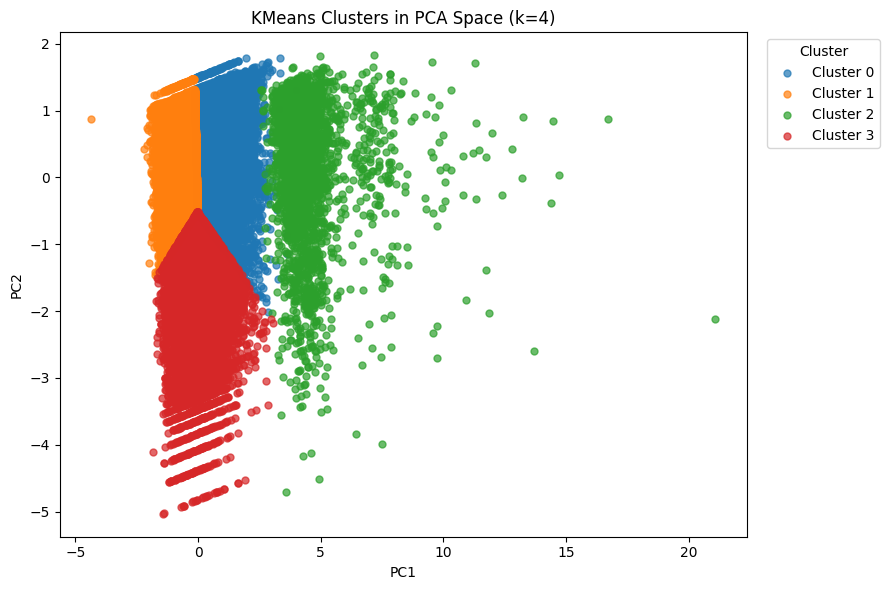

In [14]:

# =========================
# KMEANS CLUSTER SCATTER (PCA 2D)
# =========================
pca_kmeans_df = pca_df.copy()
pca_kmeans_df["cluster_kmeans"] = kmeans_labels

kmeans_scatter_plot_path = PLOT_DIR / "kmeans_cluster_scatter_pca.png"
make_cluster_scatter(
    pca_kmeans_df,
    label_col="cluster_kmeans",
    title=f"KMeans Clusters in PCA Space (k={best_k})",
    save_path=kmeans_scatter_plot_path
)


## GaussianMixture: khảo sát số components và covariance type

Phần này sẽ quét:
- `n_components = 2..10`
- `covariance_type in ["full", "diag", "tied"]`

Notebook lưu cả:
- `silhouette`
- `calinski_harabasz`
- `davies_bouldin`
- `AIC`
- `BIC`

Mô hình cuối cùng được chọn theo `silhouette` là chính và `BIC` là tiêu chí phụ.


## Cell 15: Khảo sát mô hình Gaussian Mixture Model

In [15]:

# =========================
# GMM MODEL SELECTION
# =========================
gmm_selection_results = []

for covariance_type in GMM_COVARIANCE_TYPES:
    for n_components in K_RANGE:
        model = GaussianMixture(
            n_components=n_components,
            covariance_type=covariance_type,
            n_init=5,
            max_iter=500,
            random_state=RANDOM_STATE
        )

        labels = model.fit_predict(X_scaled)

        # Trường hợp hiếm nếu GMM sinh cụm rỗng/1 nhãn, bỏ qua silhouette
        unique_labels = np.unique(labels)
        if len(unique_labels) < 2:
            silhouette = np.nan
            ch_score = np.nan
            db_score = np.nan
        else:
            silhouette = silhouette_score(X_scaled, labels)
            ch_score = calinski_harabasz_score(X_scaled, labels)
            db_score = davies_bouldin_score(X_scaled, labels)

        result = {
            "covariance_type": covariance_type,
            "n_components": n_components,
            "silhouette": silhouette,
            "calinski_harabasz": ch_score,
            "davies_bouldin": db_score,
            "aic": model.aic(X_scaled),
            "bic": model.bic(X_scaled)
        }
        gmm_selection_results.append(result)

gmm_metrics_df = pd.DataFrame(gmm_selection_results).sort_values(
    by=["silhouette", "bic"],
    ascending=[False, True]
).reset_index(drop=True)

display(Markdown("### GMM selection metrics"))
display(gmm_metrics_df.head(20))


### GMM selection metrics

,covariance_type,n_components,silhouette,calinski_harabasz,davies_bouldin,aic,bic
0,full,2,0.715384,44102.365742,0.469991,-522276.942881,-522097.503141
1,diag,2,0.715384,44102.365742,0.469991,-522120.894096,-521998.119537
2,tied,2,0.715384,44102.365742,0.469991,560151.555875,560274.330434
3,tied,3,0.457691,51020.861628,0.727720,538077.135864,538237.687210
4,full,3,0.428505,54446.570179,0.823835,-549501.573284,-549227.691575
5,diag,3,0.427360,54463.332570,0.818925,-549245.854990,-549056.971053
6,tied,4,0.390635,65336.041213,0.747066,537452.600724,537650.928858
7,diag,4,0.386099,70495.395115,0.763041,-551953.339434,-551698.346119
8,full,4,0.382820,69916.717003,0.766445,-552204.412398,-551836.088721
9,tied,5,0.350850,63538.130258,0.771377,535676.079223,535912.184144


## Cell 16: Lưu metric GMM và vẽ biểu đồ đánh giá

Đã lưu: ..\artifacts\metrics\gmm_selection_metrics.csv


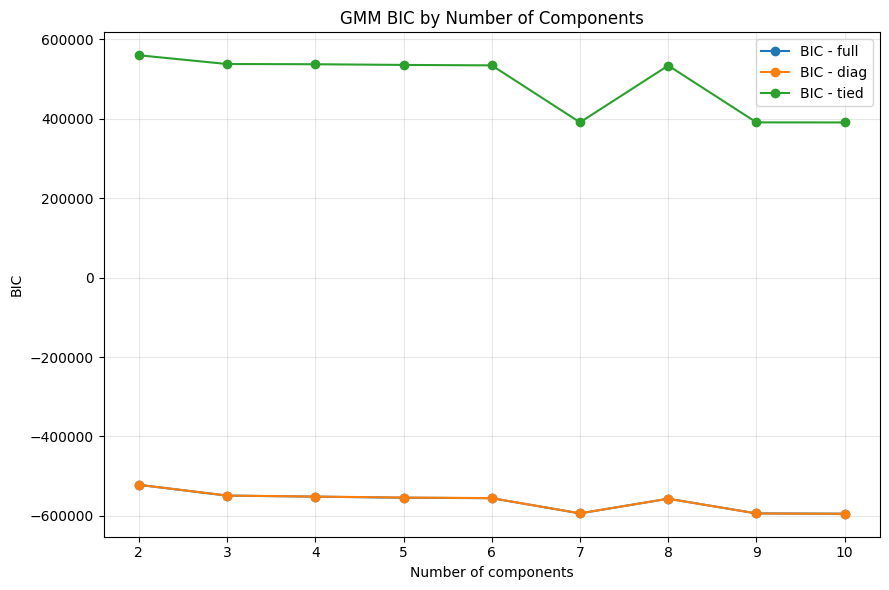

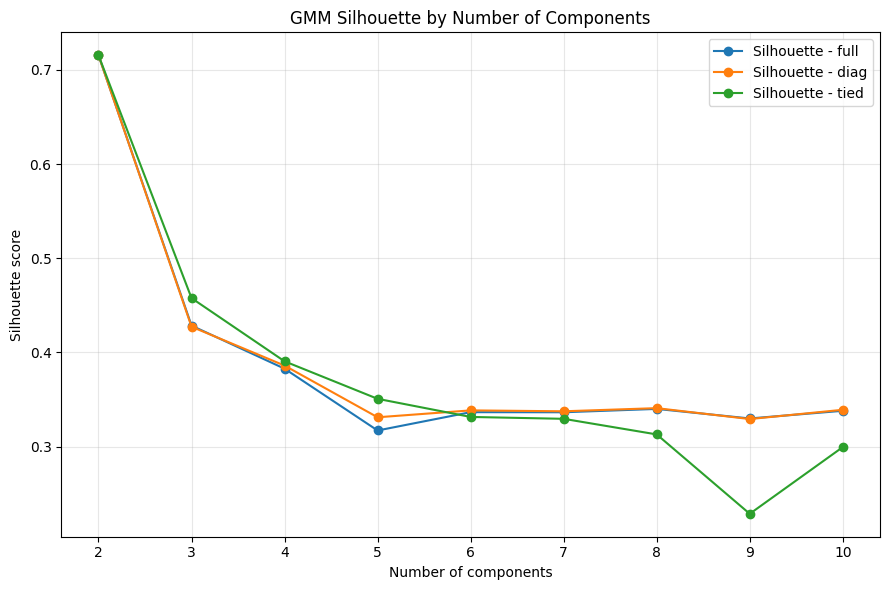

In [16]:

# =========================
# LƯU METRICS GMM + VẼ PLOT
# =========================
gmm_metrics_path = METRIC_DIR / "gmm_selection_metrics.csv"
gmm_metrics_df.to_csv(gmm_metrics_path, index=False)
print("Đã lưu:", gmm_metrics_path)

# Plot 1: BIC theo n_components cho từng covariance_type
plt.figure(figsize=(9, 6))
for cov_type in GMM_COVARIANCE_TYPES:
    subset = gmm_metrics_df[gmm_metrics_df["covariance_type"] == cov_type].sort_values("n_components")
    plt.plot(subset["n_components"], subset["bic"], marker="o", label=f"BIC - {cov_type}")

plt.title("GMM BIC by Number of Components")
plt.xlabel("Number of components")
plt.ylabel("BIC")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

gmm_bic_plot_path = PLOT_DIR / "gmm_bic_plot.png"
plt.savefig(gmm_bic_plot_path, dpi=150, bbox_inches="tight")
plt.show()

# Plot 2: Silhouette theo n_components cho từng covariance_type
plt.figure(figsize=(9, 6))
for cov_type in GMM_COVARIANCE_TYPES:
    subset = gmm_metrics_df[gmm_metrics_df["covariance_type"] == cov_type].sort_values("n_components")
    plt.plot(subset["n_components"], subset["silhouette"], marker="o", label=f"Silhouette - {cov_type}")

plt.title("GMM Silhouette by Number of Components")
plt.xlabel("Number of components")
plt.ylabel("Silhouette score")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

gmm_silhouette_plot_path = PLOT_DIR / "gmm_silhouette_plot.png"
plt.savefig(gmm_silhouette_plot_path, dpi=150, bbox_inches="tight")
plt.show()


## Cell 17: Huấn luyện mô hình GMM cuối cùng

In [17]:

# =========================
# FIT FINAL GMM
# =========================
valid_gmm_metrics_df = gmm_metrics_df.dropna(subset=["silhouette"]).copy()
if FORCE_GMM_COMPONENTS is not None:
    forced_gmm = valid_gmm_metrics_df[
        valid_gmm_metrics_df["n_components"] == FORCE_GMM_COMPONENTS
    ].sort_values(["silhouette", "bic"], ascending=[False, True])

    if forced_gmm.empty:
        raise ValueError(f"FORCE_GMM_COMPONENTS={FORCE_GMM_COMPONENTS} không hợp lệ")

    best_gmm_row = forced_gmm.iloc[0]
else:
    best_gmm_row = choose_best_gmm(valid_gmm_metrics_df)

best_gmm_components = int(best_gmm_row["n_components"])
best_gmm_covariance = str(best_gmm_row["covariance_type"])

print("Best GMM n_components:", best_gmm_components)
print("Best GMM covariance_type:", best_gmm_covariance)
display(pd.DataFrame([best_gmm_row]))

final_gmm = GaussianMixture(
    n_components=best_gmm_components,
    covariance_type=best_gmm_covariance,
    n_init=5,
    max_iter=500,
    random_state=RANDOM_STATE
)

gmm_labels = final_gmm.fit_predict(X_scaled)

rfm_clustered_gmm = rfm[[RFM_ID_COL] + RFM_FEATURES].copy()
rfm_clustered_gmm["cluster_gmm"] = gmm_labels

display(Markdown("### 5 dòng đầu của rfm_clustered_gmm"))
display(rfm_clustered_gmm.head())


Best GMM n_components: 2
Best GMM covariance_type: full


,covariance_type,n_components,silhouette,calinski_harabasz,davies_bouldin,aic,bic
0,full,2,0.715384,44102.365742,0.469991,-522276.942881,-522097.503141


### 5 dòng đầu của rfm_clustered_gmm

,customer_unique_id,recency_days,frequency_orders,monetary_value,cluster_gmm
0,0000366f3b9a7992bf8c76cfdf3221e2,112.0,1.0,141.90,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115.0,1.0,27.19,0
2,0000f46a3911fa3c0805444483337064,537.0,1.0,86.22,0
3,0000f6ccb0745a6a4b88665a16c9f078,321.0,1.0,43.62,0
4,0004aac84e0df4da2b147fca70cf8255,288.0,1.0,196.89,0


## Cell 18: Xây dựng hồ sơ cụm cho GMM

In [18]:

# =========================
# HỒ SƠ CLUSTER GMM
# =========================
gmm_profile = build_cluster_profile(rfm_clustered_gmm, "cluster_gmm")
gmm_profile = enrich_cluster_profile(
    gmm_profile,
    rfm_clustered_gmm,
    "cluster_gmm",
    orders_base_df=orders_base_final
)

gmm_profile = gmm_profile.sort_values("business_score", ascending=False).reset_index(drop=True)

display(Markdown("### GMM cluster profile"))
display(gmm_profile)


### GMM cluster profile

,cluster_gmm,customer_count,recency_days_mean,recency_days_median,frequency_orders_mean,frequency_orders_median,monetary_value_mean,monetary_value_median,customer_share_pct,business_score,segment_name,business_strategy,order_count,avg_review_score,avg_payment_value,avg_delivery_time,top_state,top_category
0,1,2801,220.294538,199.0,2.113888,2.0,308.588793,225.55,3.0,3.0,VIP / Repeat buyers,"Ưu tiên loyalty, upsell và giữ chân.",5943,4.211849,145.955252,12.308521,SP,bed_bath_table
1,0,90557,238.487616,219.0,1.000000,1.0,160.761781,105.39,97.0,-3.0,Mass / one-time customers,Tăng repeat rate bằng cross-sell cơ bản và vou...,90740,4.148030,160.842327,12.574545,SP,bed_bath_table


## Cell 19: Lưu artifact của GMM

In [19]:

# =========================
# LƯU ARTIFACT GMM
# =========================
gmm_model_path = MODEL_DIR / "gmm_model.joblib"
joblib.dump(final_gmm, gmm_model_path)

gmm_clustered_path = PRED_DIR / "rfm_clustered_gmm.csv"
rfm_clustered_gmm.to_csv(gmm_clustered_path, index=False)

gmm_profile_path = METRIC_DIR / "gmm_cluster_profile.csv"
gmm_profile.to_csv(gmm_profile_path, index=False)

print("Đã lưu model :", gmm_model_path)
print("Đã lưu labels:", gmm_clustered_path)
print("Đã lưu profile:", gmm_profile_path)


Đã lưu model : ..\artifacts\models\gmm_model.joblib
Đã lưu labels: ..\artifacts\predictions\rfm_clustered_gmm.csv
Đã lưu profile: ..\artifacts\metrics\gmm_cluster_profile.csv


## Cell 20: Trực quan hóa cụm GMM trên không gian PCA

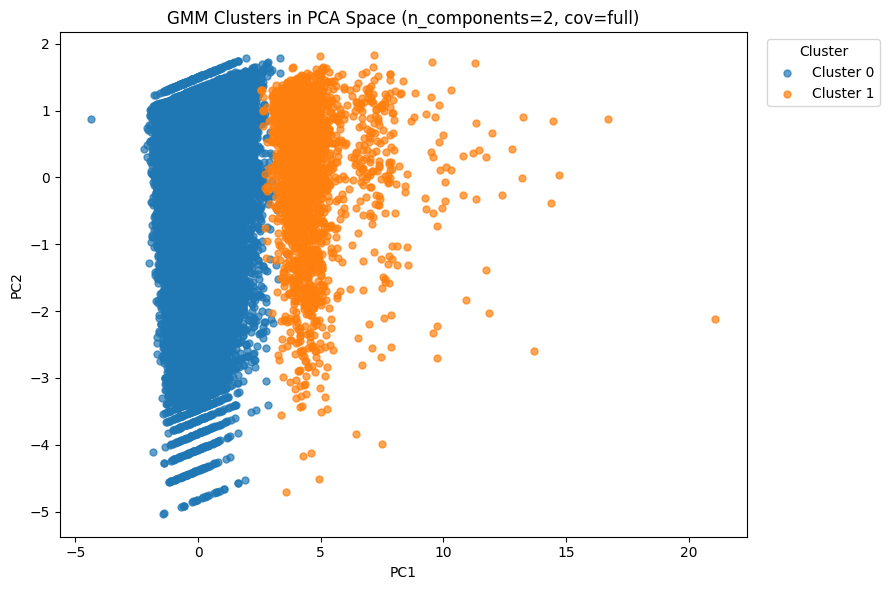

In [20]:

# =========================
# GMM CLUSTER SCATTER (PCA 2D)
# =========================
pca_gmm_df = pca_df.copy()
pca_gmm_df["cluster_gmm"] = gmm_labels

gmm_scatter_plot_path = PLOT_DIR / "gmm_cluster_scatter_pca.png"
make_cluster_scatter(
    pca_gmm_df,
    label_col="cluster_gmm",
    title=f"GMM Clusters in PCA Space (n_components={best_gmm_components}, cov={best_gmm_covariance})",
    save_path=gmm_scatter_plot_path
)


## Cell 21: So sánh KMeans và GMM

In [21]:

# =========================
# SO SÁNH KMEANS VS GMM
# =========================
final_kmeans_metrics = kmeans_metrics_df[kmeans_metrics_df["k"] == best_k].copy()
final_kmeans_metrics["model"] = "KMeans"
final_kmeans_metrics["model_detail"] = final_kmeans_metrics["k"].apply(lambda x: f"k={int(x)}")

final_gmm_metrics = valid_gmm_metrics_df[
    (valid_gmm_metrics_df["n_components"] == best_gmm_components) &
    (valid_gmm_metrics_df["covariance_type"] == best_gmm_covariance)
].copy()
final_gmm_metrics["model"] = "GaussianMixture"
final_gmm_metrics["model_detail"] = final_gmm_metrics.apply(
    lambda x: f"n={int(x['n_components'])}, cov={x['covariance_type']}", axis=1
)

comparison_cols_kmeans = {
    "k": "n_clusters",
    "inertia": "inertia",
    "silhouette": "silhouette",
    "calinski_harabasz": "calinski_harabasz",
    "davies_bouldin": "davies_bouldin"
}
comparison_cols_gmm = {
    "n_components": "n_clusters",
    "aic": "aic",
    "bic": "bic",
    "silhouette": "silhouette",
    "calinski_harabasz": "calinski_harabasz",
    "davies_bouldin": "davies_bouldin"
}

kmeans_compare = final_kmeans_metrics.rename(columns=comparison_cols_kmeans)[
    ["model", "model_detail", "n_clusters", "silhouette", "calinski_harabasz", "davies_bouldin", "inertia"]
].copy()

gmm_compare = final_gmm_metrics.rename(columns=comparison_cols_gmm)[
    ["model", "model_detail", "n_clusters", "silhouette", "calinski_harabasz", "davies_bouldin", "aic", "bic"]
].copy()

clustering_model_comparison = pd.concat([kmeans_compare, gmm_compare], ignore_index=True)

# Mức độ đồng thuận giữa 2 cách phân cụm
cluster_alignment_df = rfm_clustered_kmeans[[RFM_ID_COL, "cluster_kmeans"]].merge(
    rfm_clustered_gmm[[RFM_ID_COL, "cluster_gmm"]],
    on=RFM_ID_COL,
    how="inner"
)

agreement_ari = adjusted_rand_score(
    cluster_alignment_df["cluster_kmeans"],
    cluster_alignment_df["cluster_gmm"]
)

display(Markdown("### Clustering model comparison"))
display(clustering_model_comparison)

print("Adjusted Rand Index giữa KMeans và GMM:", round(agreement_ari, 4))


### Clustering model comparison

,model,model_detail,n_clusters,silhouette,calinski_harabasz,davies_bouldin,inertia,aic,bic
0,KMeans,k=4,4,0.395254,74003.150482,0.756469,82907.90359,NaN,NaN
1,GaussianMixture,"n=2, cov=full",2,0.715384,44102.365742,0.469991,NaN,-522276.942881,-522097.503141


Adjusted Rand Index giữa KMeans và GMM: 0.0655


## Cách dùng KMeans và GMM trong dự án

Kết quả hiện tại cho thấy:

- **GMM(2)** mạnh hơn về mặt metric thuần (`silhouette ≈ 0.7154`, `DB ≈ 0.4700`).
- **KMeans(4)** yếu hơn về silhouette nhưng phù hợp hơn cho **phân khúc khách hàng có thể hành động**.
- `Adjusted Rand Index ≈ 0.0655` cho thấy hai mô hình không kể cùng một câu chuyện phân cụm.

### Cách chốt trong notebook
- **GMM** được giữ như một **benchmark thống kê**
- **KMeans(K=4)** là mô hình **chính thức dùng cho profile cụm, báo cáo và UI**


## Cell 22: Lưu scaler, PCA, bảng so sánh và summary cuối cùng

Cell cuối sẽ lưu:

- **K tối ưu theo metric** của KMeans
- **K được chọn cuối để triển khai** của KMeans
- Kết quả tốt nhất của GMM
- Mức độ đồng thuận giữa KMeans và GMM
- Toàn bộ đường dẫn artifact để báo cáo/UI có thể nạp lại


In [22]:

# =========================
# LƯU SCALER, PCA, COMPARISON, SUMMARY
# =========================
scaler_path = MODEL_DIR / "rfm_standard_scaler.joblib"
pca_path = MODEL_DIR / "rfm_pca_2d.joblib"
comparison_path = METRIC_DIR / "clustering_model_comparison.csv"
kmeans_decision_path = METRIC_DIR / "kmeans_decision_summary.csv"

joblib.dump(scaler, scaler_path)
joblib.dump(pca_2d, pca_path)
clustering_model_comparison.to_csv(comparison_path, index=False)
kmeans_decision_df.to_csv(kmeans_decision_path, index=False)

final_summary = {
    "rfm_input_file": str(rfm_path),
    "orders_base_input_file": str(orders_base_source) if orders_base_source is not None else None,
    "use_log1p_transform": USE_LOG1P_TRANSFORM,

    "kmeans_metric_best_k": metric_best_k,
    "kmeans_metric_best_silhouette": float(metric_best_kmeans_row["silhouette"]),
    "kmeans_final_k": best_k,
    "kmeans_selection_mode": selection_mode,
    "kmeans_selection_reason": selection_reason,
    "kmeans_final_silhouette": float(best_kmeans_row["silhouette"]),
    "kmeans_final_calinski_harabasz": float(best_kmeans_row["calinski_harabasz"]),
    "kmeans_final_davies_bouldin": float(best_kmeans_row["davies_bouldin"]),
    "kmeans_final_min_cluster_share_pct": float(best_kmeans_row["min_cluster_share_pct"]),

    "gmm_best_n_components": best_gmm_components,
    "gmm_best_covariance_type": best_gmm_covariance,
    "gmm_best_silhouette": float(best_gmm_row["silhouette"]),
    "gmm_best_bic": float(best_gmm_row["bic"]),
    "cluster_agreement_adjusted_rand_index": float(agreement_ari),

    "saved_files": {
        "kmeans_metrics": str(kmeans_metrics_path),
        "kmeans_decision": str(kmeans_decision_path),
        "gmm_metrics": str(gmm_metrics_path),
        "kmeans_model": str(kmeans_model_path),
        "gmm_model": str(gmm_model_path),
        "scaler": str(scaler_path),
        "pca_2d": str(pca_path),
        "kmeans_clustered": str(kmeans_clustered_path),
        "gmm_clustered": str(gmm_clustered_path),
        "kmeans_profile": str(kmeans_profile_path),
        "gmm_profile": str(gmm_profile_path),
        "comparison": str(comparison_path),
        "kmeans_elbow_plot": str(kmeans_elbow_plot_path),
        "kmeans_silhouette_plot": str(kmeans_silhouette_plot_path),
        "kmeans_scatter_plot": str(kmeans_scatter_plot_path),
        "gmm_bic_plot": str(gmm_bic_plot_path),
        "gmm_silhouette_plot": str(gmm_silhouette_plot_path),
        "gmm_scatter_plot": str(gmm_scatter_plot_path)
    }
}

summary_path = METRIC_DIR / "clustering_final_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(final_summary, f, ensure_ascii=False, indent=2)

print("Đã lưu scaler:", scaler_path)
print("Đã lưu PCA   :", pca_path)
print("Đã lưu compare:", comparison_path)
print("Đã lưu KMeans decision:", kmeans_decision_path)
print("Đã lưu summary:", summary_path)

display(Markdown("### Final summary"))
display(pd.DataFrame([final_summary]))


Đã lưu scaler: ..\artifacts\models\rfm_standard_scaler.joblib
Đã lưu PCA   : ..\artifacts\models\rfm_pca_2d.joblib
Đã lưu compare: ..\artifacts\metrics\clustering_model_comparison.csv
Đã lưu KMeans decision: ..\artifacts\metrics\kmeans_decision_summary.csv
Đã lưu summary: ..\artifacts\metrics\clustering_final_summary.json


### Final summary

,rfm_input_file,orders_base_input_file,use_log1p_transform,kmeans_metric_best_k,kmeans_metric_best_silhouette,kmeans_final_k,kmeans_selection_mode,kmeans_selection_reason,kmeans_final_silhouette,kmeans_final_calinski_harabasz,kmeans_final_davies_bouldin,kmeans_final_min_cluster_share_pct,gmm_best_n_components,gmm_best_covariance_type,gmm_best_silhouette,gmm_best_bic,cluster_agreement_adjusted_rand_index,saved_files
0,..\data\processed\rfm_df.parquet,..\data\processed\orders_base_final.parquet,True,2,0.715384,4,forced_manual_final,K tối ưu theo metric là k=2 (silhouette=0.7154...,0.395254,74003.150482,0.756469,3.000278,2,full,0.715384,-522097.503141,0.06555,{'kmeans_metrics': '..\artifacts\metrics\kmean...


## Kết quả đầu ra chính của notebook 05

Notebook này tạo ra các artifact chính sau:

- `artifacts/metrics/kmeans_k_selection_metrics.csv`
- `artifacts/metrics/kmeans_decision_summary.csv`
- `artifacts/metrics/gmm_selection_metrics.csv`
- `artifacts/metrics/kmeans_cluster_profile.csv`
- `artifacts/metrics/gmm_cluster_profile.csv`
- `artifacts/metrics/clustering_model_comparison.csv`
- `artifacts/metrics/clustering_final_summary.json`
- `artifacts/models/kmeans_model.joblib`
- `artifacts/models/gmm_model.joblib`
- `artifacts/models/rfm_standard_scaler.joblib`
- `artifacts/models/rfm_pca_2d.joblib`
- `artifacts/predictions/rfm_clustered_kmeans.csv`
- `artifacts/predictions/rfm_clustered_gmm.csv`
- `artifacts/plots/kmeans_elbow_plot.png`
- `artifacts/plots/kmeans_silhouette_plot.png`
- `artifacts/plots/kmeans_cluster_scatter_pca.png`
- `artifacts/plots/gmm_bic_plot.png`
- `artifacts/plots/gmm_silhouette_plot.png`
- `artifacts/plots/gmm_cluster_scatter_pca.png`

### Kết luận của notebook
- **K tối ưu theo metric của KMeans:** lưu riêng trong summary
- **K được chọn cuối để triển khai:** `K = 4`
- **GMM:** dùng để đối chiếu/benchmark, không thay thế KMeans làm segmentation chính


## CHECK-IN — FILE 05: `05_clustering_rfm.ipynb`

### A. THIẾT LẬP BAN ĐẦU
- [x] Hoàn thành import thư viện cho notebook clustering
- [x] Hoàn thành cấu hình cảnh báo
- [x] Hoàn thành khai báo cấu hình chung cho notebook
- [x] Hoàn thành khai báo:
  - `BASE_DIR`
  - `PROCESSED_DIR`
  - `ARTIFACT_DIR`
  - `MODEL_DIR`
  - `METRIC_DIR`
  - `PLOT_DIR`
  - `PRED_DIR`
- [x] Hoàn thành khai báo:
  - `RANDOM_STATE`
  - `K_RANGE`
  - `GMM_COVARIANCE_TYPES`
  - `USE_LOG1P_TRANSFORM`

---

### B. HÀM HỖ TRỢ
- [x] Hoàn thành định nghĩa các hàm hỗ trợ dùng chung cho notebook clustering
- [x] Hoàn thành hàm phục vụ lưu file / chuẩn hóa đường dẫn / hỗ trợ profiling / hỗ trợ đánh giá clustering

---

### C. ĐỌC DỮ LIỆU ĐẦU VÀO
- [x] Hoàn thành đọc `rfm_df.parquet`
- [x] Hoàn thành đọc thêm `orders_base_final.parquet` để enrich profile
- [x] Hoàn thành hiển thị sample của `rfm_df`
- [x] Hoàn thành in `rfm_df shape`

---

### D. KIỂM TRA VÀ LÀM SẠCH DỮ LIỆU RFM
- [x] Hoàn thành kiểm tra số dòng trước làm sạch
- [x] Hoàn thành kiểm tra số dòng sau làm sạch
- [x] Hoàn thành kiểm tra số dòng bị loại
- [x] Hoàn thành kiểm tra duplicate customer
- [x] Hoàn thành kiểm tra missing values của:
  - `customer_unique_id`
  - `recency_days`
  - `frequency_orders`
  - `monetary_value`

---

### E. THỐNG KÊ MÔ TẢ DỮ LIỆU RFM
- [x] Hoàn thành thống kê mô tả cho:
  - `recency_days`
  - `frequency_orders`
  - `monetary_value`
- [x] Hoàn thành tính `skewness` cho các biến RFM
- [x] Hoàn thành vẽ histogram của:
  - `recency_days`
  - `frequency_orders`
  - `monetary_value`

---

### F. CHUẨN BỊ FEATURE CHO CLUSTERING
- [x] Hoàn thành chuẩn bị 3 feature đầu vào:
  - `recency_days`
  - `frequency_orders`
  - `monetary_value`
- [x] Hoàn thành áp dụng `log1p` transform
- [x] Hoàn thành chuẩn hóa bằng `StandardScaler`
- [x] Hoàn thành tạo:
  - `X_scaled`
  - các cột scaled trong DataFrame
- [x] Hoàn thành hiển thị sample sau scaling
- [x] Hoàn thành in `X_scaled shape`

---

### G. GIẢM CHIỀU BẰNG PCA
- [x] Hoàn thành fit PCA 2 chiều
- [x] Hoàn thành tạo:
  - `PC1`
  - `PC2`
- [x] Hoàn thành tính `explained_variance_ratio`
- [x] Hoàn thành hiển thị bảng explained variance

---

### H. KHẢO SÁT KMEANS VỚI NHIỀU GIÁ TRỊ K
- [x] Hoàn thành khảo sát `KMeans` với `k` từ 2 đến 10
- [x] Hoàn thành tính các metric cho từng `k`:
  - `inertia`
  - `silhouette`
  - `calinski_harabasz`
  - `davies_bouldin`
  - `min_cluster_share_pct`
- [x] Hoàn thành tạo bảng `kmeans_metrics_df`

---

### I. LƯU METRIC KMEANS VÀ VẼ BIỂU ĐỒ CHỌN K
- [x] Hoàn thành lưu `kmeans_k_selection_metrics.csv`
- [x] Hoàn thành vẽ biểu đồ `inertia`
- [x] Hoàn thành vẽ biểu đồ `silhouette`

---

### J. HUẤN LUYỆN MÔ HÌNH KMEANS CUỐI CÙNG
- [x] Hoàn thành tạo bảng quyết định chọn `k`
- [x] Hoàn thành lưu thông tin:
  - `metric_optimal`
  - `final_selected`
- [x] Hoàn thành huấn luyện `KMeans` cuối cùng
- [x] Hoàn thành tạo nhãn `cluster_kmeans`
- [x] Hoàn thành hiển thị sample dữ liệu có nhãn cụm
- [x] Hoàn thành in `Final KMeans k`

---

### K. XÂY DỰNG HỒ SƠ CỤM CHO KMEANS
- [x] Hoàn thành tạo `kmeans_profile`
- [x] Hoàn thành tính cho từng cụm:
  - `customer_count`
  - `recency_days_mean`
  - `recency_days_median`
  - `frequency_orders_mean`
  - `frequency_orders_median`
  - `monetary_value_mean`
  - `monetary_value_median`
  - `customer_share_pct`
  - `business_score`
  - `segment_name`
  - `business_strategy`
  - `order_count`
  - `avg_review_score`
  - `avg_payment_value`
  - `avg_delivery_time`
  - `top_state`
  - `top_category`

---

### L. LƯU ARTIFACT CỦA KMEANS
- [x] Hoàn thành lưu `kmeans_model.joblib`
- [x] Hoàn thành lưu `rfm_clustered_kmeans.csv`
- [x] Hoàn thành lưu `kmeans_cluster_profile.csv`

---

### M. TRỰC QUAN HÓA KMEANS TRÊN KHÔNG GIAN PCA
- [x] Hoàn thành vẽ scatter plot KMeans trên PCA 2D
- [x] Hoàn thành lưu hình trực quan hóa KMeans

---

### N. KHẢO SÁT GAUSSIAN MIXTURE MODEL
- [x] Hoàn thành khảo sát `GaussianMixture`
- [x] Hoàn thành thử nhiều `n_components`
- [x] Hoàn thành thử nhiều `covariance_type`
- [x] Hoàn thành tính các metric cho từng cấu hình:
  - `silhouette`
  - `calinski_harabasz`
  - `davies_bouldin`
  - `aic`
  - `bic`
- [x] Hoàn thành tạo bảng `gmm_metrics_df`

---

### O. LƯU METRIC GMM VÀ VẼ BIỂU ĐỒ ĐÁNH GIÁ
- [x] Hoàn thành lưu `gmm_selection_metrics.csv`
- [x] Hoàn thành vẽ biểu đồ đánh giá GMM
- [x] Hoàn thành vẽ biểu đồ `BIC`
- [x] Hoàn thành vẽ biểu đồ `silhouette` cho GMM

---

### P. HUẤN LUYỆN MÔ HÌNH GMM CUỐI CÙNG
- [x] Hoàn thành chọn `Best GMM n_components`
- [x] Hoàn thành chọn `Best GMM covariance_type`
- [x] Hoàn thành huấn luyện GMM cuối cùng
- [x] Hoàn thành tạo nhãn `cluster_gmm`
- [x] Hoàn thành hiển thị sample dữ liệu có nhãn GMM

---

### Q. XÂY DỰNG HỒ SƠ CỤM CHO GMM
- [x] Hoàn thành tạo `gmm_profile`
- [x] Hoàn thành tính cho từng cụm:
  - `customer_count`
  - `recency_days_mean`
  - `recency_days_median`
  - `frequency_orders_mean`
  - `frequency_orders_median`
  - `monetary_value_mean`
  - `monetary_value_median`
  - `customer_share_pct`
  - `business_score`
  - `segment_name`
  - `business_strategy`
  - `order_count`
  - `avg_review_score`
  - `avg_payment_value`
  - `avg_delivery_time`
  - `top_state`
  - `top_category`

---

### R. LƯU ARTIFACT CỦA GMM
- [x] Hoàn thành lưu `gmm_model.joblib`
- [x] Hoàn thành lưu `rfm_clustered_gmm.csv`
- [x] Hoàn thành lưu `gmm_cluster_profile.csv`

---

### S. TRỰC QUAN HÓA GMM TRÊN KHÔNG GIAN PCA
- [x] Hoàn thành vẽ scatter plot GMM trên PCA 2D
- [x] Hoàn thành lưu hình trực quan hóa GMM

---

### T. SO SÁNH KMEANS VÀ GMM
- [x] Hoàn thành tạo bảng so sánh `KMeans` và `GaussianMixture`
- [x] Hoàn thành tổng hợp các metric so sánh:
  - `n_clusters`
  - `silhouette`
  - `calinski_harabasz`
  - `davies_bouldin`
  - `inertia`
  - `aic`
  - `bic`
- [x] Hoàn thành tính `Adjusted Rand Index` giữa KMeans và GMM
- [x] Hoàn thành hiển thị bảng `clustering_model_comparison`

---

### U. LƯU SCALER / PCA / BẢNG SO SÁNH / SUMMARY CUỐI
- [x] Hoàn thành lưu `rfm_standard_scaler.joblib`
- [x] Hoàn thành lưu `rfm_pca_2d.joblib`
- [x] Hoàn thành lưu `clustering_model_comparison.csv`
- [x] Hoàn thành lưu `kmeans_decision_summary.csv`
- [x] Hoàn thành tạo `clustering_final_summary`
- [x] Hoàn thành lưu `clustering_final_summary.json`

---

### V. TỔNG HỢP KẾT QUẢ ĐẦU RA CHÍNH
- [x] Hoàn thành phần **đọc dữ liệu RFM**
- [x] Hoàn thành phần **kiểm tra và làm sạch dữ liệu RFM**
- [x] Hoàn thành phần **thống kê mô tả dữ liệu RFM**
- [x] Hoàn thành phần **chuẩn bị feature cho clustering**
- [x] Hoàn thành phần **giảm chiều PCA**
- [x] Hoàn thành phần **khảo sát KMeans với nhiều giá trị k**
- [x] Hoàn thành phần **lưu metric và biểu đồ chọn k của KMeans**
- [x] Hoàn thành phần **huấn luyện KMeans cuối cùng**
- [x] Hoàn thành phần **xây dựng hồ sơ cụm KMeans**
- [x] Hoàn thành phần **lưu artifact KMeans**
- [x] Hoàn thành phần **trực quan hóa KMeans**
- [x] Hoàn thành phần **khảo sát GaussianMixture**
- [x] Hoàn thành phần **lưu metric và biểu đồ đánh giá GMM**
- [x] Hoàn thành phần **huấn luyện GMM cuối cùng**
- [x] Hoàn thành phần **xây dựng hồ sơ cụm GMM**
- [x] Hoàn thành phần **lưu artifact GMM**
- [x] Hoàn thành phần **trực quan hóa GMM**
- [x] Hoàn thành phần **so sánh KMeans và GMM**
- [x] Hoàn thành phần **lưu scaler, PCA, bảng so sánh và final summary**

### Kết luận cuối:
Notebook `05_clustering_rfm.ipynb` đã **hoàn thành** toàn bộ các hạng mục chính thuộc phạm vi **RFM Clustering, KMeans Survey, KMeans Final Model, GMM Survey, GMM Final Model, Cluster Profiling, PCA Visualization, Model Comparison, Artifact Saving, và Final Summary** của riêng file này.